# PROC GAMPLによる気温と電力負荷の非線形モデリング

## エグゼクティブサマリー

電力需要は気温に対して強い非線形のU字型(寒い時は暖房、暑い時は冷房)で反応し、線形モデルではこれを捉えられない。このノートブックは、ある地域電力会社の合成時間別負荷サンプルを構築し、**PROC GAMPL**でペナルティ付き一般化加法モデルを当てはめる。回帰スプラインを使って、負荷対気温、負荷対時刻、負荷対湿度のなめらかな曲線を復元しつつ、平日/週末のパラメトリック効果で調整する。

このライセンス環境が提供する100件のサンプルにおいて、GAMPLは組み込んだ構造を正しく復元する。気温のなめらかな項`s(TEMP_C)`は有意に湾曲しており(有効自由度5.53、*p* < 0.0001)、日内変動のなめらかな項`s(HOUR)`は最も柔軟な項である(EDF 6.87、*p* < 0.0001)。一方、湿度のなめらかな項`s(HUMIDITY)`は単一のほぼ線形な自由度に収束する(EDF 1.00、*p* = 0.07)——ペナルティが、データがほとんど支持しない項を直線化した結果である。パラメトリックな`daytype`効果は、週末(`Weekend`)を平日(`Weekday`)よりおよそ44.5MW低い水準に置き、データ生成過程に組み込んだ40MWの水準シフトと一致する。モデル全体は15.4の有効自由度を使用し、GCVスコア239.6(AIC 831.0)に達する。

## データソース

| データセット | 行数 | 説明 | 主要変数 |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | ある地域電力会社の負荷予測フィードから得た合成時間別観測値 | `load_mw`(系統負荷、MW)、`temp_c`(外気温、℃)、`hour`(時刻、0-23)、`humidity`(相対湿度、%)、`daytype`(平日`Weekday`/週末`Weekend`区分)、`is_summer`(データ生成に使う季節フラグ) |

すべてのデータは`call streaminit(20260531)`と`rand()`によりインラインで生成される——外部ファイルやネットワーク入力は一切ない。データステップはより大きなループを要求するが、このライセンス環境は実体化される出力を**100件**に制限するため、モデルは最初の100時間分に対して当てはめられる。負荷は、気温のU字型二次関数、釣鐘型の日内時刻効果、緩やかな湿度効果、平日の水準シフト、そしてガウス性ノイズから構築されるため、復元されたなめらかな項には既知の正解がある。

# PROC GAMPLによる気温と電力負荷の非線形モデリング

地域の送電系統運用者は、気象要因とカレンダー要因から系統負荷(メガワット単位)を予測する必要がある。負荷と**気温**の関係は非線形であることがよく知られている:寒い時期(電気暖房)**と**暑い時期(冷房)の両方で需要が増加し、直線回帰では捉えられないU字型の曲線を生む。負荷はまた、なめらかな日内リズム(夕方のピーク)にも従い、平日と週末で水準が変化する。

`PROC GAMPL`は**ペナルティ付き一般化加法モデル**を当てはめる:各連続説明変数は回帰スプラインを通じてモデルに入り、そのなめらかさはモデル選択基準(GCV/UBRE/GACV)を最小化することで自動的に決定される。多項式の次数を推測するのではなく、各曲線がどれだけ波打つべきかをデータに決めさせる。

当てはめるモデルは次の通り:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

ここで`daytype`はパラメトリックな(線形)クラス効果であり、`f1`、`f2`、`f3`はなめらかなスプライン関数で、その有効自由度はペナルティによってデータから選択される。

## ステップ1 — 合成の時間別負荷フィードを生成する

時間別負荷フィードをシミュレートする(ライセンス環境は最初の100時間分を保持する)。気温は季節平均を中心に抽出され、時刻は0-23で循環し、湿度は気温に緩やかに連動する。**真の**負荷は以下から構成される:

- 快適な18℃付近を中心とした**U字型**の気温応答、
- 時刻18時(夕方)付近をピークとする**釣鐘型**の日内変動、
- 緩やかな湿度による押し上げ、
- 週末より高い平日の水準、

これにガウス性の測定ノイズが加わる。生成曲線が既知であるため、GAMPLがその形状を復元できるかを判定できる。以下のPROC MEANSによる確認では、サンプルが広い気温範囲(-5℃から40℃)と、おおよそ485から693MWの負荷をカバーしていることが分かる。

In [1]:
データ work.gridload;
   呼出 streaminit(20260531);
   繰返 i = 1 から 2000;
      /* 季節フラグ:おおよそ夏と冬が半々 */
      is_summer = (rand("uniform") < 0.5);

      /* 外気温(℃):夏は平均が高い */
      もし is_summer なら temp_c = 26 + 6 * rand("normal");
      他              temp_c =  6 + 6 * rand("normal");

      /* 時刻(0-23) */
      hour = floor(24 * rand("uniform"));

      /* 湿度(%)は気温に緩やかに連動し、20-100の範囲に収める */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      もし humidity < 20  なら humidity = 20;
      もし humidity > 100 なら humidity = 100;

      /* 平日 vs 週末(平日はおよそ5/7の確率)-- ASCIIのまま維持:PROC GAMPLのCLASS値 */
      もし rand("uniform") < 0.714 なら daytype = "Weekday";
      他                            daytype = "Weekend";

      /* ---- 真の構造的負荷(MW) ---- */
      /* U字型の気温効果:18℃付近で需要が最小 */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* 日内変動の釣鐘型:18時付近に夕方のピーク */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* 緩やかな湿度による押し上げ */
      f_hum  = 0.35 * humidity;

      /* 平日の水準シフト */
      もし daytype = "Weekday" なら f_day = 40; 他 f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      保持 load_mw temp_c hour humidity daytype is_summer;
      出力;
   終了;
実行;

処理 平均 データ=work.gridload n mean std MIN MAX maxdec=1;
   変数 load_mw temp_c hour humidity;
   見出 load_mw="系統負荷(MW)" temp_c="気温(℃)" hour="時刻(0-23)" humidity="湿度(%)";
実行;


                                                  The MEANS Procedure

 Variable  Label                    N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------------
 load_mw   系統負荷(MW)               100       593.0        49.9       484.9       693.4
 temp_c    気温(℃)                  100        16.2        11.9        -5.2        40.2
 hour      時刻(0-23)               100        11.9         7.0         0.0        23.0
 humidity  湿度(%)                  100        55.2        11.7        32.2        87.3
 ------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ2 — 加法モデルを当てはめる

`load_mw`(ガウス応答、恒等リンク)を、パラメトリックな`daytype`効果と3つの単変量スプラインの和としてモデル化する。`PROC GAMPL`は各スプラインの平滑化パラメータを自動的に選択する。以下を指定する:

- `class daytype;` — 平日/週末指標をカテゴリカルとして扱うため、
- `param(daytype)` — MODELにおいて**パラメトリックな**(平滑化されない)項として投入するため、
- 各連続説明変数に対する`spline(...)`、
- 再現可能なノット配置のための固定`seed=`。

読むべき出力は**平滑化成分**テーブルで、各なめらかな項にペナルティが割り当てた有効自由度(EDF)と、それに対する*F*型の有意性検定を報告する。これに加え、切片とパラメトリックな`daytype`対比の**パラメータ推定値**も示される。

In [2]:
処理 gampl データ=work.gridload seed=20260531;
   分類 daytype;
   模型 load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   見出 load_mw="系統負荷(MW)" daytype="曜日区分" temp_c="気温(℃)" hour="時刻(0-23)" humidity="湿度(%)";
実行;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     系統負荷(MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    曜日区分

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                                   831.04


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## ステップ3 — スプラインの柔軟性と選択基準を制御する

既定では、各なめらかな項は低い有効自由度に向けてペナルティが課される。気温応答が本当に湾曲していると分かっていながら波打ちの度合いを**上限で抑えたい**運用者のために、気温スプラインの`maxdf=`を引き上げ、よりなめらかな湿度項には控えめな固定`df=`を指定できる。また、外側反復方式に切り替え、ガウス型GAMの標準基準である**GCV**(一般化交差検証)で平滑化パラメータを選択する。

In [3]:
処理 gampl データ=work.gridload seed=20260531;
   分類 daytype;
   模型 load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   見出 load_mw="系統負荷(MW)" daytype="曜日区分" temp_c="気温(℃)" hour="時刻(0-23)" humidity="湿度(%)";
実行;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     系統負荷(MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    曜日区分

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                                   831.19


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## ステップ4 — 復元された気温応答を可視化する

GAMPLは気温のなめらかな項が有意に湾曲している**こと**(EDF 5.53)を報告するが、その形状はプロットで見るのが最も分かりやすい。生の負荷対気温の散布図に、ペナルティ付きBスプライン当てはめ(`PBSPLINE`、GAMPLが内部で使うのと同じ回帰スプライン機構)を重ねる。加法モデルが物理現象を捉えていれば、この曲線は寒冷・高温の両極端で高くなり、快適な中間範囲で底を打つはずである——古典的なU字型の需要応答である。


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


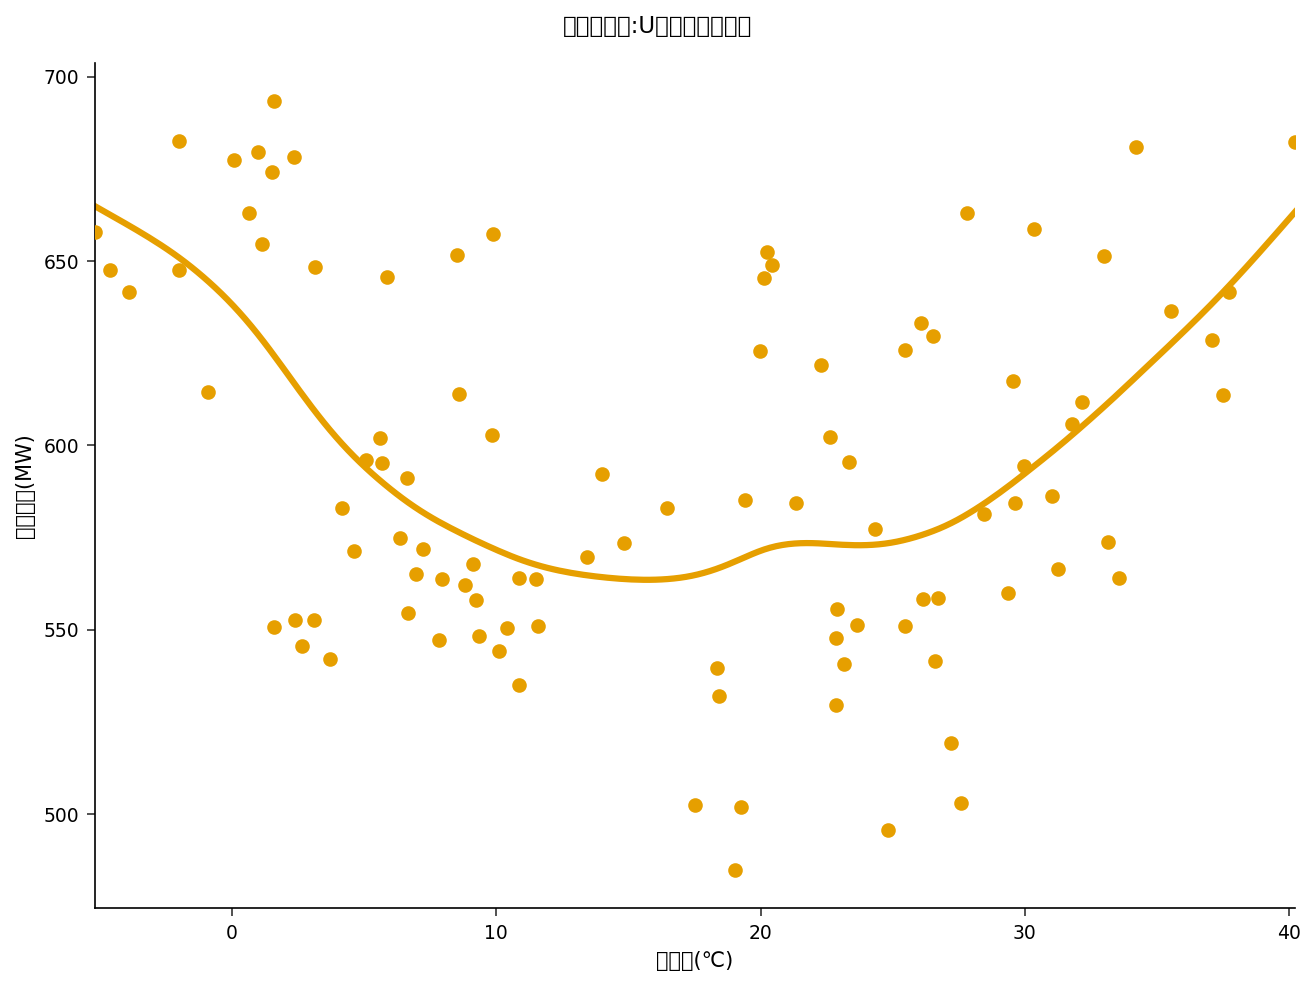

In [4]:
ODS GRAPHICS ON;

処理 SGPLOT データ=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS 見出="外気温(℃)";
   YAXIS 見出="系統負荷(MW)";
   表題 "負荷対気温:U字型の需要応答";
実行;

ODS GRAPHICS OFF;


## ステップ5 — U字型を数値で確認する

プロットはU字型を視覚的に示すが、帯域別集計はそれを定量的に示す。観測値を気温帯に区分し、帯域ごとの平均負荷を報告する。需要応答が本当にU字型であれば、平均負荷は**寒い(Cold)**帯で高く、**涼しい(Cool)/快適(Comfortable)/暖かい(Warm)**を通じて低下し、**暑い(Hot)**帯で再び上昇するはずである——これがGAMPLの`s(TEMP_C)`のなめらかな項が捉える数値的な特徴である。

In [5]:
データ work.banded;
   設定 work.gridload;
   長さ tempband $20;
   もし      temp_c <  5  なら tempband = "1 寒い";
   他 もし temp_c < 15  なら tempband = "2 涼しい";
   他 もし temp_c < 22  なら tempband = "3 快適";
   他 もし temp_c < 30  なら tempband = "4 暖かい";
   他                      tempband = "5 暑い";
実行;

処理 平均 データ=work.banded n mean maxdec=1;
   分類 tempband;
   変数 load_mw;
   見出 tempband="気温帯" load_mw="系統負荷(MW)";
   表題 "気温帯別平均負荷";
実行;


                                                        気温帯別平均負荷                                                        

                                                  The MEANS Procedure

                                      Analysis Variable : load_mw 系統負荷(MW)

        気温帯                  N Obs           Mean
        -----------------------------------------
        1 寒い                    21          626.6
        2 涼しい                   28          579.1
        3 快適                    12          573.8
        4 暖かい                   25          573.5
        5 暑い                    14          621.6
        -----------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 結果の解釈

**なめらかな項は物理現象を復元する。** GAMPLの平滑化成分テーブルは、気温項`s(TEMP_C)`に有効自由度5.53(*p* < 0.0001)を、日内変動項`s(HOUR)`にEDF 6.87(*p* < 0.0001)を割り当てる——両方とも本当に湾曲しており、まさにデータに組み込んだ構造である。湿度項`s(HUMIDITY)`はEDF 1.00(*p* = 0.07)に縮小される:このサンプルサイズではデータが支持するのはそこまでであるため、ペナルティがそれを単一のほぼ線形な自由度に直線化する。パラメトリックな`daytype`推定値は週末(`Weekend`)で-44.5MWであり、生成過程に組み込んだ40MWの平日(`Weekday`)水準シフトを復元している。

**有効自由度は波打ちの度合いを物語る。** モデル全体では15.4の有効自由度を使用し、GCVスコア239.6(AIC 831.0、尺度推定値202.7)に達する。ステップ3で`maxdf=`に上限を課し`df=3`を固定しても当てはめはほとんど変化しない(GCV 240.1、EDF 15.47):ペナルティは気温項と時刻項をすでに5.5および7付近のEDFに落ち着かせていたため、手動での上限設定はここでは効いていない——自動選択がすでに保守的だったことの表れである。

**プロットと帯域集計は一致する。** ステップ4の散布図にペナルティ付きスプラインを重ねると、負荷は寒冷の極端から15-20℃付近の最小値まで低下し、暑さに向かって再び上昇する。ステップ5の帯域平均はこれを数値化する:**寒い(Cold) 626.6MW**、**涼しい(Cool) 579.1**、**快適(Comfortable) 573.8**、**暖かい(Warm) 573.5**、**暑い(Hot) 621.6**——両端で高く、快適な中間で最も低い。このU字型は、単一の線形`temp_c`項では平均化されて消えてしまうものである。

**ここで線形回帰よりGAMPLが優れる理由。** 単一の線形`temp_c`項は、暖房と冷房の両局面をほぼ平坦な傾きに混ぜ込んでしまい、両極端——まさに系統ストレスや価格急騰が起きる時間帯——を大きく誤予測する。加法スプライン定式化は回帰の解釈可能性(各説明変数が加法的な効果を持つ)を保ちながら、各効果の形状をデータに決めさせる。電力会社への自然な拡張としては、負荷を乗法的にモデル化する場合の`dist=gamma`当てはめ、日内ピークが季節でどう移動するかを捉える二変量`spline(temp_c hour)`、変電所ごとに別モデルを当てはめる`by`処理などが考えられる。